In [1]:
import torch
import torch.nn as nn
from torch.optim import SGD
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = torch.tensor([[6, 2], [5, 2], [1, 3], [7,6]]).float()
y = torch.tensor([1,5,2,5]).float()

In [3]:
x

tensor([[6., 2.],
        [5., 2.],
        [1., 3.],
        [7., 6.]])

In [4]:
y

tensor([1., 5., 2., 5.])

Define a matrix that takes in a 2d vector and returns an 8d vector

In [7]:
M1 = nn.Linear(2, 8, bias = False)
M1

Linear(in_features=2, out_features=8, bias=False)

In [8]:
M1(x)

tensor([[ 1.9764,  0.9196, -3.3599,  2.6171,  0.0828, -2.4031, -4.0656, -3.4652],
        [ 1.6500,  0.8463, -2.7702,  2.0679,  0.2893, -1.7851, -3.6133, -3.0236],
        [ 0.3533,  0.7925, -0.3223, -0.4680,  1.7765,  1.3390, -2.4802, -1.6649],
        [ 2.3386,  1.9518, -3.5930,  1.8100,  2.5203, -0.4117, -7.2217, -5.5378]],
       grad_fn=<MmBackward0>)

This can be chained with a second matrix M2

In [9]:
M2 = nn.Linear(8, 1, bias = False)
M2

Linear(in_features=8, out_features=1, bias=False)

In [10]:
M2(M1(x))

tensor([[-3.1595],
        [-2.6364],
        [-0.5543],
        [-3.7241]], grad_fn=<MmBackward0>)

In [12]:
M2(M1(x)).shape

torch.Size([4, 1])

In [13]:
# Use the squeeze function to eliminate the extra dimension
M2(M1(x)).squeeze()

tensor([-3.1595, -2.6364, -0.5543, -3.7241], grad_fn=<SqueezeBackward0>)

Now to construct the network f to optimize for the weights a (weights of the matrices M1 and M2) defined above

In [18]:
class MyNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.Matrix1 = nn.Linear(2, 8, bias = False)
        self.Matrix2 = nn.Linear(8, 1, bias = False)
    def forward(self, x):
        x = self.Matrix1(x)
        x = self.Matrix2(x)
        return x.squeeze()

In [19]:
f = MyNeuralNet()

In [20]:
for par in f.parameters():
    print(par)

Parameter containing:
tensor([[ 0.4038, -0.5193],
        [ 0.6454, -0.0820],
        [ 0.2371,  0.6694],
        [-0.2580,  0.2702],
        [ 0.2584, -0.1355],
        [-0.2710, -0.3192],
        [-0.4376, -0.4660],
        [ 0.4477,  0.1506]], requires_grad=True)
Parameter containing:
tensor([[ 0.1731,  0.0543, -0.3270,  0.1423,  0.0108, -0.2516,  0.3179,  0.2761]],
       requires_grad=True)


In [21]:
yhat = f(x)
yhat

tensor([-0.3280, -0.3741, -0.8613, -1.4918], grad_fn=<SqueezeBackward0>)

In [22]:
y

tensor([1., 5., 2., 5.])

Adjustin a so that y and yhat are similar

Now to define a Loss function L, which provides a metric of similarity between y and yhat. The RMSE will be used.

In [23]:
L = nn.MSELoss()
L(y, yhat)

tensor(20.2438, grad_fn=<MseLossBackward0>)

Confirming that this is the same as the regular RMSE

In [24]:
torch.mean((y-yhat)**2)

tensor(20.2438, grad_fn=<MeanBackward0>)

In [25]:
# To optimize using gradient descent(SGD)
opt = SGD(f.parameters(), lr = 0.001)

In [26]:
losses = []
for _ in range(50):
    opt.zero_grad() #Flush previous epoch's gradient
    loss_value = L(f(x), y) #Compute loss
    loss_value.backward() #Compute gradient
    opt.step() #Perform iteration using gradient above
    losses.append(loss_value.item())

Plot L(a) as a function of number of iterations

Text(0.5, 0, 'Epochs')

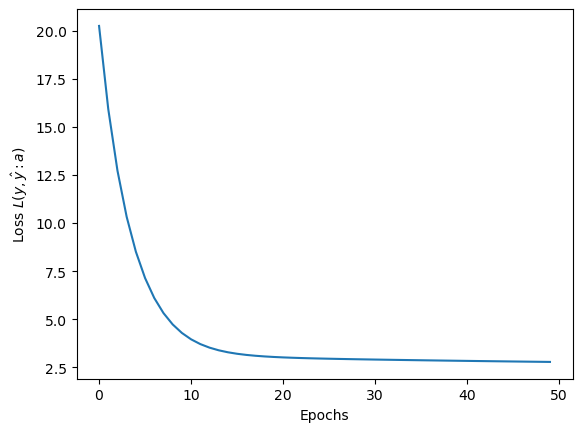

In [27]:
plt.plot(losses)
plt.ylabel('Loss $L (y, \hat{y}:a)$')
plt.xlabel('Epochs')

In [28]:
f(x)

tensor([3.4636, 2.9524, 1.1058, 4.7676], grad_fn=<SqueezeBackward0>)

In [29]:
y

tensor([1., 5., 2., 5.])